## Method 3: Mini-Rockte + MLP **V3**

we will be:

* using Mini-Rocket as our feature extractor 
* replacing the Logistic regression with Keras MLP 
* thus, LIME and SHAP would work better 

**Note:** the model will be trained **BZT,COC,DOP** as we have more samples 

In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sktime.transformations.panel.rocket import MiniRocket
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import joblib, numpy as np, torch
from torch.utils.data import DataLoader, TensorDataset


### Load

In [ ]:
# Load aligned and balanced dataset
X_all = np.load("models/v3/X_all.npy")       # shape (n_samples, 87)
y_all = np.load("models/v3/y_all.npy")       # numeric labels
y_labels = np.load("models/v3/y_labels.npy", allow_pickle=True) # original label strings

# Reshape for MiniRocket: (samples, channels=1, timesteps=87)
X_all_reshaped = X_all.reshape(X_all.shape[0], 1, X_all.shape[1])

# Train/test split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(X_all_reshaped, y_all, test_size=0.2, stratify=y_all, random_state=42)


### Mini Rocket transformation 

In [ ]:
# Fit MiniRocket on training data only
rocket = MiniRocket()
rocket.fit(X_train_raw)

# Transform both sets
X_train = rocket.transform(X_train_raw)  # shape (n_samples, ~9996)
X_val = rocket.transform(X_val_raw)

# Save transformer for deployment
joblib.dump(rocket, "models/v3/minirocket_transformer.joblib")


['models/v3/minirocket_transformer.joblib']

### Transforming to tensor 

In [ ]:
# Ensure output is a 2D NumPy array
X_train = np.asarray(X_train)
X_val = np.asarray(X_val)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create datasets and loaders
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=64)


### MLP model

In [ ]:
class MiniRocketMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(MiniRocketMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.dropout1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.3)
        self.out = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        return self.out(x)


### Training the Model

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MiniRocketMLP(input_dim=X_train.shape[1], num_classes=len(y_labels)).to(device)
np.save("models/v3/minirocket_input_dim.npy", np.array([X_train.shape[1]]))
print(f"📏 Saved MiniRocket input_dim: {X_train.shape[1]}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

best_val_acc = 0.0
patience = 5
counter = 0

for epoch in range(50):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)
    val_acc = correct / total
    print(f"Epoch {epoch+1}: Val Accuracy = {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping.")
            break

model.load_state_dict(best_model_state)
torch.save(model.state_dict(), "models/v3/Mini-RocketMLP.pt")
print("✅ Model saved")

📏 Saved MiniRocket input_dim: 9996
Epoch 1: Val Accuracy = 0.9161
Epoch 2: Val Accuracy = 0.9861
Epoch 3: Val Accuracy = 0.9907
Epoch 4: Val Accuracy = 0.9931
Epoch 5: Val Accuracy = 0.9936
Epoch 6: Val Accuracy = 0.9716
Epoch 7: Val Accuracy = 0.9716
Epoch 8: Val Accuracy = 0.9959
Epoch 9: Val Accuracy = 0.9965
Epoch 10: Val Accuracy = 0.9959
Epoch 11: Val Accuracy = 0.9959
Epoch 12: Val Accuracy = 0.9959
Epoch 13: Val Accuracy = 0.9896
Epoch 14: Val Accuracy = 0.9913
Early stopping.
✅ Model saved


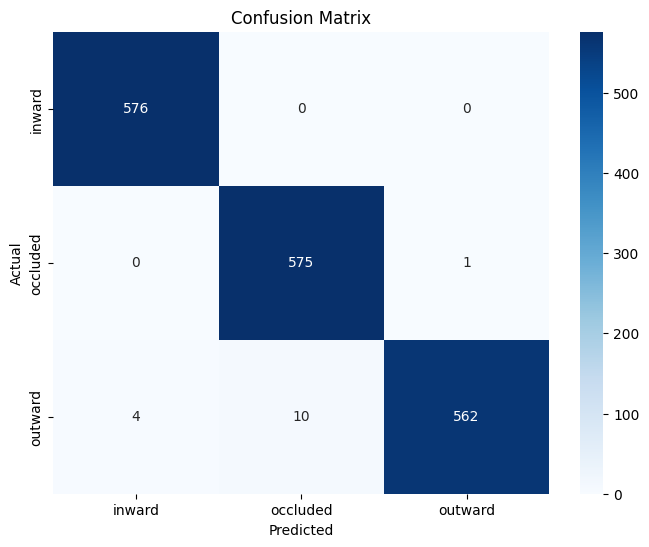

              precision    recall  f1-score   support

      inward       0.99      1.00      1.00       576
    occluded       0.98      1.00      0.99       576
     outward       1.00      0.98      0.99       576

    accuracy                           0.99      1728
   macro avg       0.99      0.99      0.99      1728
weighted avg       0.99      0.99      0.99      1728

Multi-class AUC: 1.0000


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluation on validation set
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_labels, yticklabels=y_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Precision, Recall, F1-score
report = classification_report(y_true, y_pred, target_names=y_labels)
print(report)

# ROC-AUC
if len(y_labels) == 2:
    auc = roc_auc_score(y_true, [p[1] for p in y_prob])
    print(f"AUC: {auc:.4f}")
else:
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    print(f"Multi-class AUC: {auc:.4f}")

### Saving the labels for XAI

In [ ]:
# Save test set and label encoder mapping
np.save("models/v3/X_val.npy", X_val)
np.save("models/v3/y_val.npy", y_val)
np.save("models/v3/y_labels.npy", y_labels)
